k     P(X=k)      npᵢ (теор.)     nᵢ (емпір.)
----------------------------------------------
0     0.4066      20.3285         24
1     0.3659      18.2956         17
2     0.1647      8.2330          5
3     0.0494      2.4699          4
4     0.0111      0.5557          0
5     0.0020      0.1000          0
6     0.0003      0.0150          0


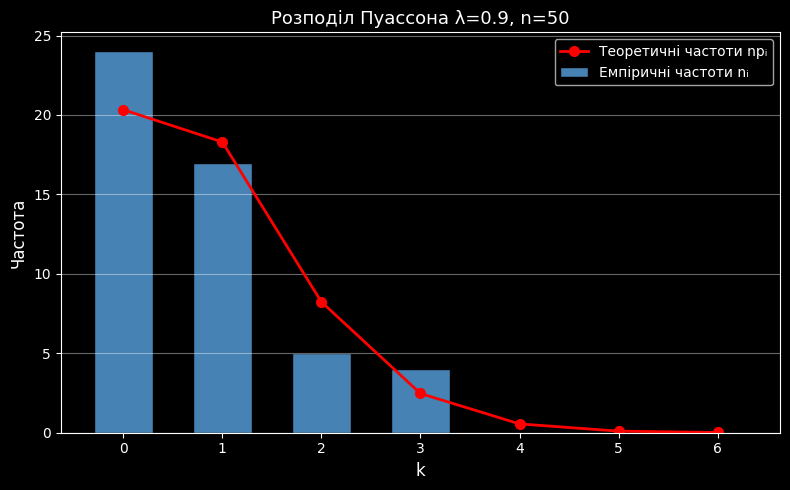

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import math

lam = 0.9
n = 50
np.random.seed(42)

Y = np.random.rand(n)
sample = []
for y in Y:
    k = 0
    p = math.exp(-lam)
    F = p
    while y > F:
        k += 1
        p = p * lam / k
        F += p
    sample.append(k)
sample = np.array(sample)

bins = math.ceil(1 + 3.322 * np.log10(n))  # = 7
k_values = np.arange(0, bins)

probs = [(lam**k * math.exp(-lam)) / math.factorial(k) for k in k_values]
theor_counts = [n * p for p in probs]
emp_counts = [np.sum(sample == k) for k in k_values]

# Таблиця в консолі
print(f"{'k':<6}{'P(X=k)':<12}{'npᵢ (теор.)':<16}{'nᵢ (емпір.)'}")
print("-" * 46)
for k, p, tc, ec in zip(k_values, probs, theor_counts, emp_counts):
    print(f"{k:<6}{p:<12.4f}{tc:<16.4f}{ec}")

# Гістограма
plt.figure(figsize=(8, 5))
plt.bar(k_values, emp_counts, width=0.6, color='steelblue', edgecolor='black', label='Емпіричні частоти nᵢ')
plt.plot(k_values, theor_counts, 'ro-', linewidth=2, markersize=7, label='Теоретичні частоти npᵢ')
plt.title('Розподіл Пуассона λ=0.9, n=50', fontsize=13)
plt.xlabel('k', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.xticks(k_values)
plt.legend()
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

Кількість інтервалів за формулою Стерджеса: k = 7

Змодельовані значення:
1.1693
2.7275
1.5510
1.3557
1.0582
1.0582
1.0201
1.9550
1.3585
1.5074
1.0070
3.2151
1.8139
1.0828
1.0692
1.0699
1.1285
1.2814
1.2075
1.1216
1.3709
1.0514
1.1221
1.1643
1.2250
1.6697
1.0771
1.2721
1.3487
1.0160
1.3659
1.0643
1.0227
2.6945
3.0757
1.7346
1.1287
1.0349
1.4685
1.2133
1.0443
1.2559
1.0117
2.2259
1.1050
1.4363
1.1326
1.2772
1.3018
1.0705


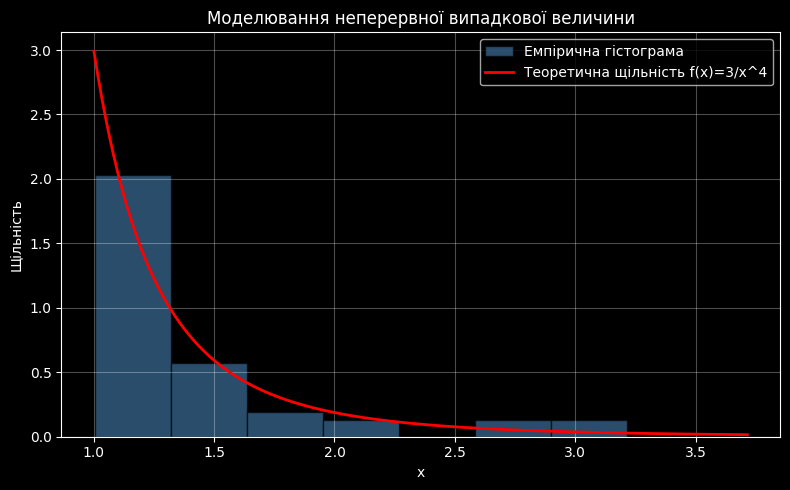

In [19]:
import numpy as np
import matplotlib.pyplot as plt

n = 50
np.random.seed(42)

# рівномірно розподілені випадкові числа
Y = np.random.rand(n)

X = (1 / (1 - Y)) ** (1/3)

# кількість інтервалів за Стерджесом
k = int(np.ceil(1 + 3.322 * np.log10(n)))
print(f"Кількість інтервалів за формулою Стерджеса: k = {k}")

print("\nЗмодельовані значення:")
for value in X:
    print(f"{value:.4f}")

# теоретична щільність
x_theor = np.linspace(1.001, max(X) + 0.5, 500)
f_theor = 3 / (x_theor ** 4)

# графік
plt.figure(figsize=(8, 5))

plt.hist(X, bins=k, density=True, alpha=0.6,
         edgecolor='black', color='steelblue',
         label='Емпірична гістограма')

plt.plot(x_theor, f_theor, 'r-', linewidth=2,
         label='Теоретична щільність f(x)=3/x^4')

plt.title('Моделювання випадкової величини')
plt.xlabel('x')
plt.ylabel('Щільність')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Кількість інтервалів (Стерджес): 7

Змодельовані значення:
[1.1693 2.7275 1.551  1.3557 1.0582 1.0582 1.0201 1.955  1.3585 1.5074
 1.007  3.2151 1.8139 1.0828 1.0692 1.0699 1.1285 1.2814 1.2075 1.1216
 1.3709 1.0514 1.1221 1.1643 1.225  1.6697 1.0771 1.2721 1.3487 1.016
 1.3659 1.0643 1.0227 2.6945 3.0757 1.7346 1.1287 1.0349 1.4685 1.2133
 1.0443 1.2559 1.0117 2.2259 1.105  1.4363 1.1326 1.2772 1.3018 1.0705]


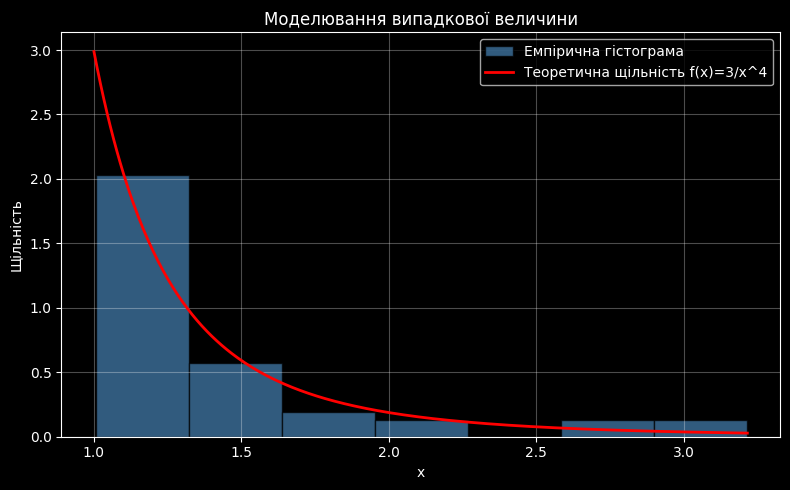

In [22]:
import numpy as np
import matplotlib.pyplot as plt

n = 50
np.random.seed(42)

# 1. рівномірні значення
Y = np.random.rand(n)

# 2. обернена функція розподілу
X = (1 / (1 - Y)) ** (1/3)

# 3. Стерджес
bins = int(np.ceil(1 + 3.322 * np.log10(n)))
print("Кількість інтервалів (Стерджес):", bins)

print("\nЗмодельовані значення:")
print(np.round(X, 4))

# 4. теоретична щільність
x_theor = np.linspace(1.001, max(X), 400)
f_theor = 3 / (x_theor ** 4)

# 5. графік
plt.figure(figsize=(8,5))

plt.hist(X, bins=bins, density=True,
         color='steelblue', edgecolor='black',
         alpha=0.7, label='Емпірична гістограма')

plt.plot(x_theor, f_theor, 'r-', linewidth=2,
         label='Теоретична щільність f(x)=3/x^4')

plt.title('Моделювання випадкової величини')
plt.xlabel('x')
plt.ylabel('Щільність')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()